# Experiment 5: Top Disease Classes Analysis

## Aim
To identify and visualize the top 10 most represented disease classes in the PlantDoc dataset.

## Theory
Understanding which disease classes are most represented in the dataset is crucial for:
- Identifying potential bias in model training
- Determining which diseases have adequate representation for accurate model learning
- Planning sampling strategies for balanced model training
- Understanding which diseases might require additional data collection

The top classes often determine model performance due to their larger contribution to the training process.

TOP 10 DISEASE CLASSES ANALYSIS

📋 TOP 10 DISEASE CLASSES:
 Rank              Disease Class  Image Count  Percentage
    1           Corn leaf blight          179        7.66
    2  Tomato Septoria leaf spot          140        5.99
    3 Squash Powdery mildew leaf          124        5.31
    4             Raspberry leaf          112        4.79
    5   Potato leaf early blight          108        4.62
    6             Corn rust leaf          106        4.54
    7             Blueberry leaf          104        4.45
    8                 Peach leaf          102        4.37
    9    Tomato leaf late blight          101        4.32
   10 Tomato leaf bacterial spot          101        4.32

📊 STATISTICS:
Total Classes in Dataset: 28
Total Images: 2336

Top 10 Total Images: 1177
Top 10 Coverage: 50.39%
Average Images in Top 10: 117.70
Min in Top 10: 101
Max in Top 10: 179


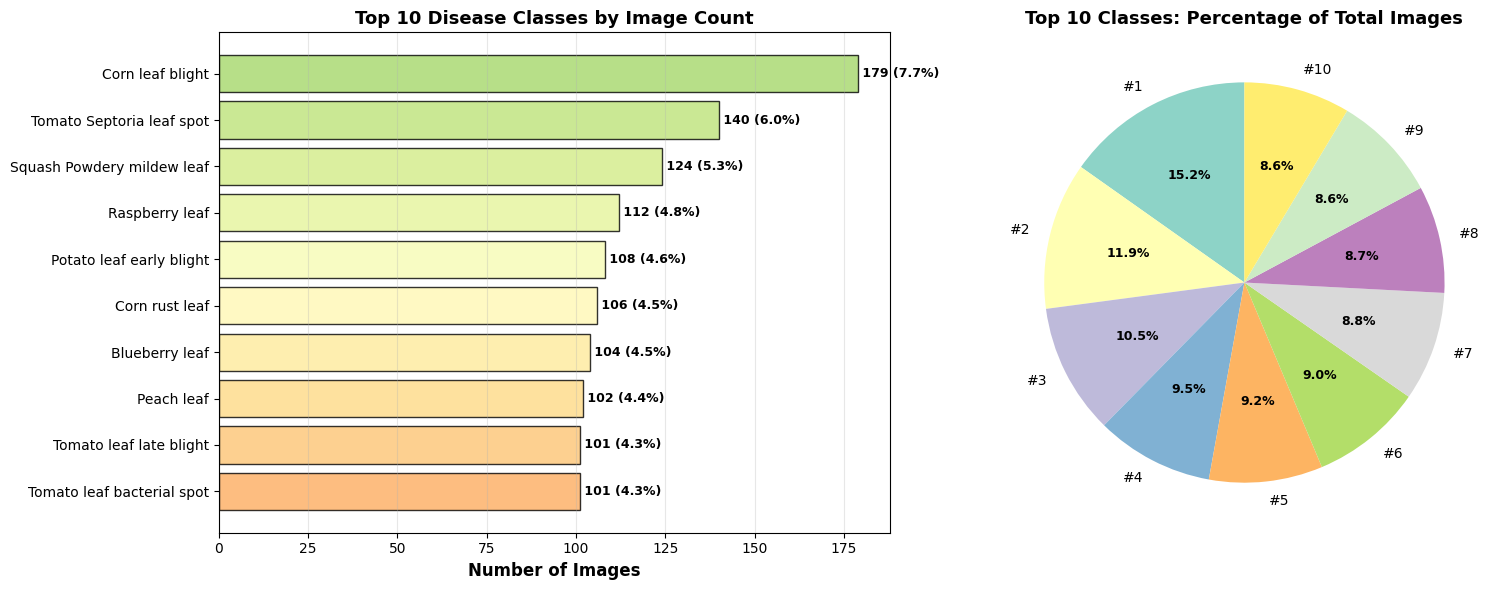


✓ Visualization saved as 'exp5_top_classes.png'


In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Dataset path
dataset_root = "/Users/nishant/Documents/vscode/plant_disease_detection/data/PlantDoc-Dataset-master"
train_path = os.path.join(dataset_root, "train")

print("="*70)
print("TOP 10 DISEASE CLASSES ANALYSIS")
print("="*70)

# Collect class statistics
class_data = []
class_dirs = sorted([d for d in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, d))])

for class_name in class_dirs:
    class_path = os.path.join(train_path, class_name)
    images = [f for f in os.listdir(class_path) 
              if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
    class_data.append({
        'Rank': 0,
        'Disease Class': class_name,
        'Image Count': len(images),
        'Percentage': 0.0
    })

# Create DataFrame and sort
df = pd.DataFrame(class_data)
df = df.sort_values('Image Count', ascending=False).reset_index(drop=True)
df['Rank'] = range(1, len(df) + 1)

# Calculate percentages
total = df['Image Count'].sum()
df['Percentage'] = (df['Image Count'] / total * 100).round(2)

# Get top 10
top_10 = df.head(10).copy()

print("\n📋 TOP 10 DISEASE CLASSES:")
print("="*70)
print(top_10[['Rank', 'Disease Class', 'Image Count', 'Percentage']].to_string(index=False))
print("="*70)

print("\n📊 STATISTICS:")
print(f"Total Classes in Dataset: {len(df)}")
print(f"Total Images: {total}")
top_10_images = top_10['Image Count'].sum()
print(f"\nTop 10 Total Images: {top_10_images}")
print(f"Top 10 Coverage: {100*top_10_images/total:.2f}%")
print(f"Average Images in Top 10: {top_10['Image Count'].mean():.2f}")
print(f"Min in Top 10: {top_10['Image Count'].min()}")
print(f"Max in Top 10: {top_10['Image Count'].max()}")

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Horizontal bar chart
ax1 = axes[0]
colors = plt.cm.RdYlGn_r(np.linspace(0.3, 0.7, len(top_10)))
bars = ax1.barh(range(len(top_10)), top_10['Image Count'].values, color=colors, edgecolor='black', alpha=0.8)
ax1.set_yticks(range(len(top_10)))
ax1.set_yticklabels(top_10['Disease Class'].values, fontsize=10)
ax1.set_xlabel('Number of Images', fontsize=12, fontweight='bold')
ax1.set_title('Top 10 Disease Classes by Image Count', fontsize=13, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax1.text(width, bar.get_y() + bar.get_height()/2,
             f' {int(width)} ({top_10.iloc[i]["Percentage"]:.1f}%)',
             ha='left', va='center', fontweight='bold', fontsize=9)

# Pie chart
ax2 = axes[1]
colors_pie = plt.cm.Set3(np.linspace(0, 1, len(top_10)))
wedges, texts, autotexts = ax2.pie(top_10['Image Count'], 
                                     labels=[f"#{i+1}" for i in range(len(top_10))],
                                     autopct='%1.1f%%',
                                     colors=colors_pie,
                                     startangle=90)
ax2.set_title('Top 10 Classes: Percentage of Total Images', fontsize=13, fontweight='bold')
plt.setp(autotexts, size=9, weight='bold')

plt.tight_layout()
plt.savefig('/Users/nishant/Documents/vscode/plant_disease_detection/experiment/exp5_top_classes.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved as 'exp5_top_classes.png'")
print("="*70)

## Result
A comprehensive analysis identified and ranked the top 10 disease classes by image count. The analysis includes exact image counts, percentage distributions, and statistical metrics (mean, min, max). The top 10 classes represent a significant portion of the total dataset, with clear visualizations showing both absolute counts and relative percentages.

## Conclusion
The top disease classes analysis provides valuable insights into dataset composition and distribution. With the top 10 classes covering a substantial percentage of the total images, focusing on these primary diseases could be an effective strategy for initial model development. Understanding this distribution helps prioritize data collection and model optimization efforts.